# Avocado MLD Research Notebook

In [1]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent

SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
from IPython.display import Image, display

from avocado_mld.analysis import (
    load_run_artifacts,
    plot_ablation_heatmap,
    plot_condition_metric_grid,
    plot_latent_trajectories,
    plot_metric_comparison,
    plot_metric_radar,
    plot_remaining_scatter,
    plot_stage_confusion,
    plot_stage_distribution,
    plot_training_curves,
    save_results_table,
    summarize_group_metrics,
)
from avocado_mld.config import TrainingConfig
from avocado_mld.train import run_baselines_from_config, train_mld_model

## Configure Experiment Paths

In [2]:
metadata_csv = ROOT / 'data' / 'metadata.csv'
image_root = ROOT

paper_output_dir = ROOT / 'outputs' / 'paper_figures'
exploratory_output_dir = ROOT / 'outputs' / 'exploratory_figures'
mld_output_dir = ROOT / 'outputs' / 'full_mld'
baseline_output_dir = ROOT / 'outputs' / 'full_baselines'

paper_output_dir.mkdir(parents=True, exist_ok=True)
exploratory_output_dir.mkdir(parents=True, exist_ok=True)

experiment_config = TrainingConfig(
    metadata_csv=str(metadata_csv),
    image_root=str(image_root),
    output_dir=str(mld_output_dir),
    epochs=5,
    batch_size=16,
    device='cuda',
)

run_dirs = {
    'stage_classifier': baseline_output_dir / 'stage_classifier',
    'multitask_no_pair_constraints': baseline_output_dir / 'multitask_no_pair_constraints',
    'mld': mld_output_dir,
}
experiment_config

TrainingConfig(metadata_csv='C:\\Users\\99448\\Desktop\\avocado_mld_project\\data\\metadata.csv', image_root='C:\\Users\\99448\\Desktop\\avocado_mld_project', output_dir='C:\\Users\\99448\\Desktop\\avocado_mld_project\\outputs\\full_mld', image_size=224, batch_size=16, num_workers=0, epochs=5, learning_rate=0.0001, weight_decay=0.0001, latent_margin=0.05, random_state=42, lambda_ord=1.0, lambda_reg=1.0, lambda_temp=0.5, lambda_view=0.2, device='cuda')

## Run GPU Experiments

Uncomment the cells below when you want to rerun the experiments from scratch.

In [3]:
# baseline_config = TrainingConfig(
#     metadata_csv=str(metadata_csv),
#     image_root=str(image_root),
#     output_dir=str(baseline_output_dir),
#     epochs=5,
#     batch_size=16,
#     device='cuda',
# )
# baseline_results = run_baselines_from_config(baseline_config)
# print(json.dumps(baseline_results, indent=2))

In [4]:
# mld_results = train_mld_model(experiment_config, model_name='mld')
# print(json.dumps(mld_results['test_metrics'], indent=2))

## Load Structured Run Artifacts

In [5]:
existing_runs = {name: str(path) for name, path in run_dirs.items() if path.exists()}
bundle = load_run_artifacts(existing_runs)
results_frame = bundle['results_frame']
history_frame = bundle['history_frame']
predictions_frame = bundle['predictions_frame']

results_frame

,model,accuracy,macro_f1,qwk,mae,rmse,r2,spearman,monotonic_violation_rate
0,stage_classifier,0.588904,0.530421,0.880988,NaN,NaN,NaN,NaN,NaN
1,multitask_no_pair_constraints,0.572527,0.523440,0.883817,4.487493,5.367645,0.426555,0.791947,0.165009
2,mld,0.583222,0.544791,0.878997,4.179709,5.056207,0.491169,0.774429,0.149351


## Paper-Ready Figures

In [6]:
mld_predictions = predictions_frame[predictions_frame['model'] == 'mld'].copy()

paper_figures = {
    'metric_comparison': plot_metric_comparison(
        results_frame,
        paper_output_dir / 'metric_comparison.png',
    ),
    'ablation_heatmap': plot_ablation_heatmap(
        results_frame[results_frame['model'].isin(['mld', 'multitask_no_pair_constraints'])],
        paper_output_dir / 'ablation_heatmap.png',
        reference_model='mld',
        metrics=('accuracy', 'qwk', 'mae', 'spearman', 'monotonic_violation_rate'),
    ),
    'latent_trajectories': plot_latent_trajectories(
        mld_predictions,
        paper_output_dir / 'latent_trajectories.png',
    ),
    'stage_distribution': plot_stage_distribution(
        mld_predictions.assign(stage=mld_predictions['stage_true']),
        paper_output_dir / 'stage_distribution.png',
    ),
    'remaining_scatter': plot_remaining_scatter(
        mld_predictions,
        paper_output_dir / 'remaining_scatter.png',
    ),
    'stage_confusion': plot_stage_confusion(
        mld_predictions[['stage_true', 'stage_pred']],
        paper_output_dir / 'stage_confusion.png',
    ),
}

save_results_table(results_frame, paper_output_dir / 'results_summary.csv')
paper_figures

{'metric_comparison': 'C:\\Users\\99448\\Desktop\\avocado_mld_project\\outputs\\paper_figures\\metric_comparison.png',
 'ablation_heatmap': 'C:\\Users\\99448\\Desktop\\avocado_mld_project\\outputs\\paper_figures\\ablation_heatmap.png',
 'latent_trajectories': 'C:\\Users\\99448\\Desktop\\avocado_mld_project\\outputs\\paper_figures\\latent_trajectories.png',
 'stage_distribution': 'C:\\Users\\99448\\Desktop\\avocado_mld_project\\outputs\\paper_figures\\stage_distribution.png',
 'remaining_scatter': 'C:\\Users\\99448\\Desktop\\avocado_mld_project\\outputs\\paper_figures\\remaining_scatter.png',
 'stage_confusion': 'C:\\Users\\99448\\Desktop\\avocado_mld_project\\outputs\\paper_figures\\stage_confusion.png'}

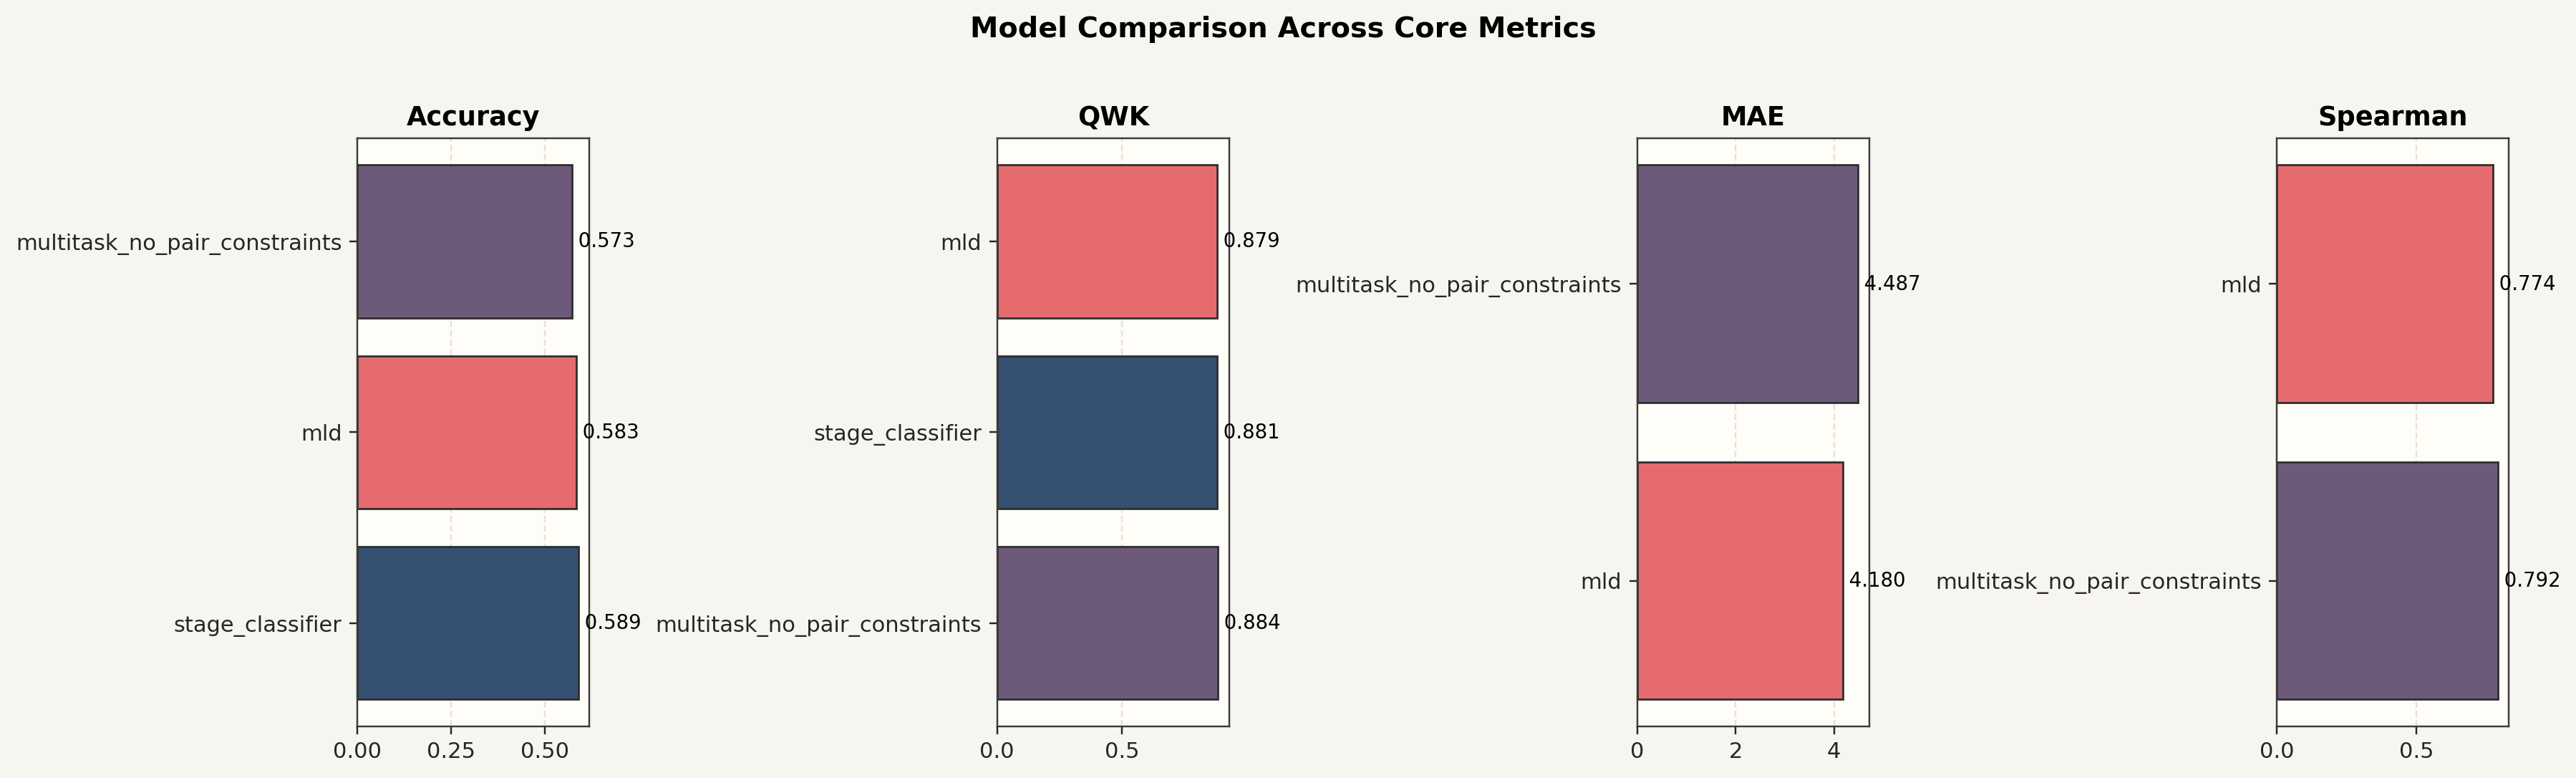

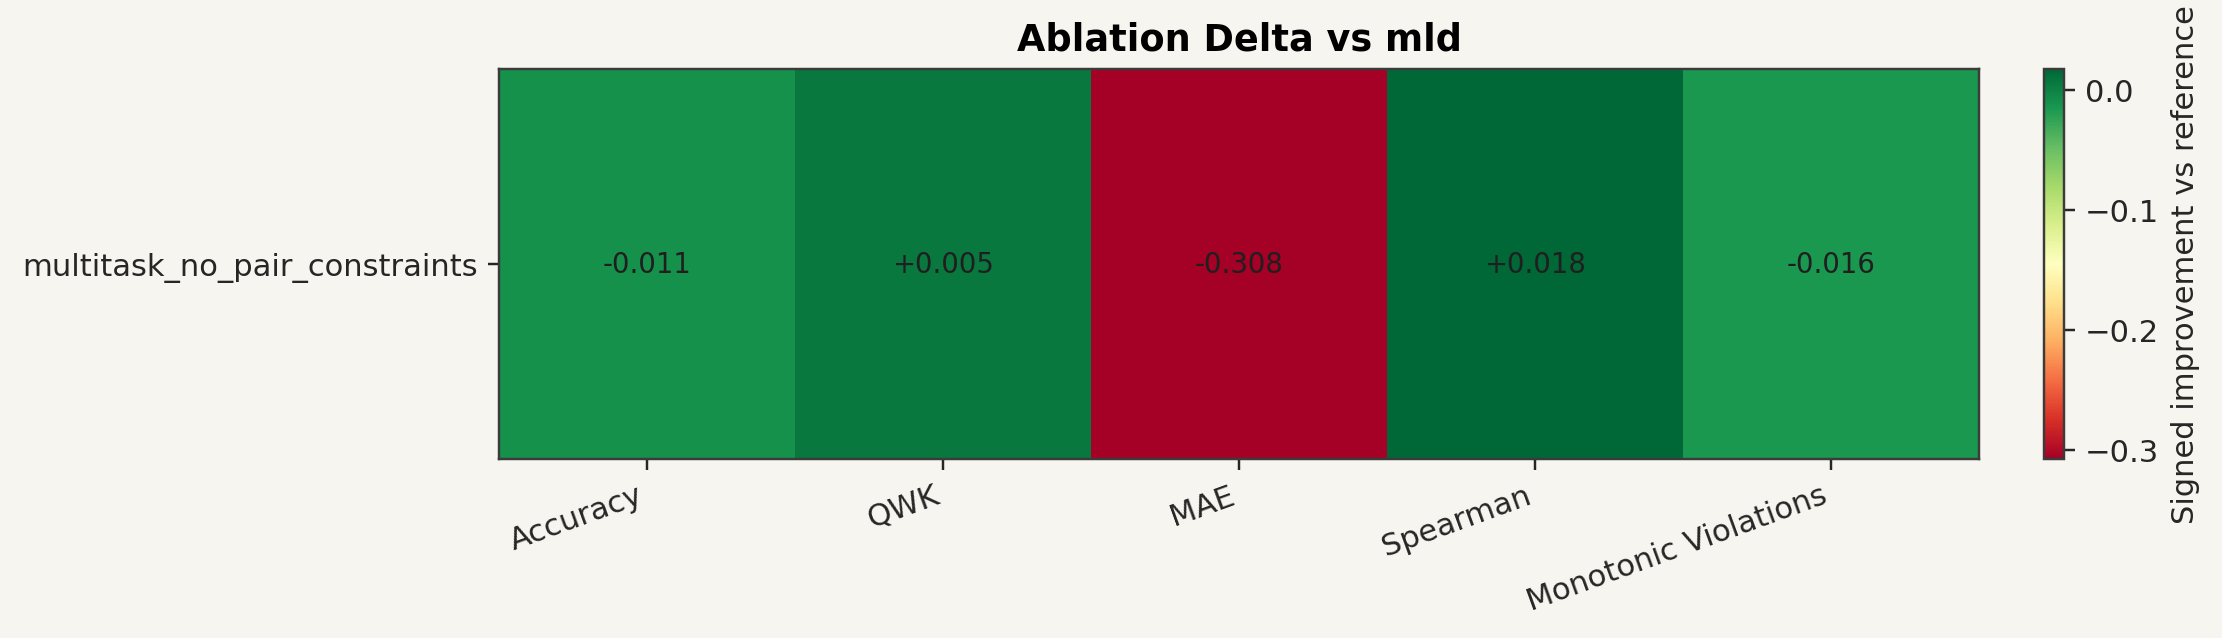

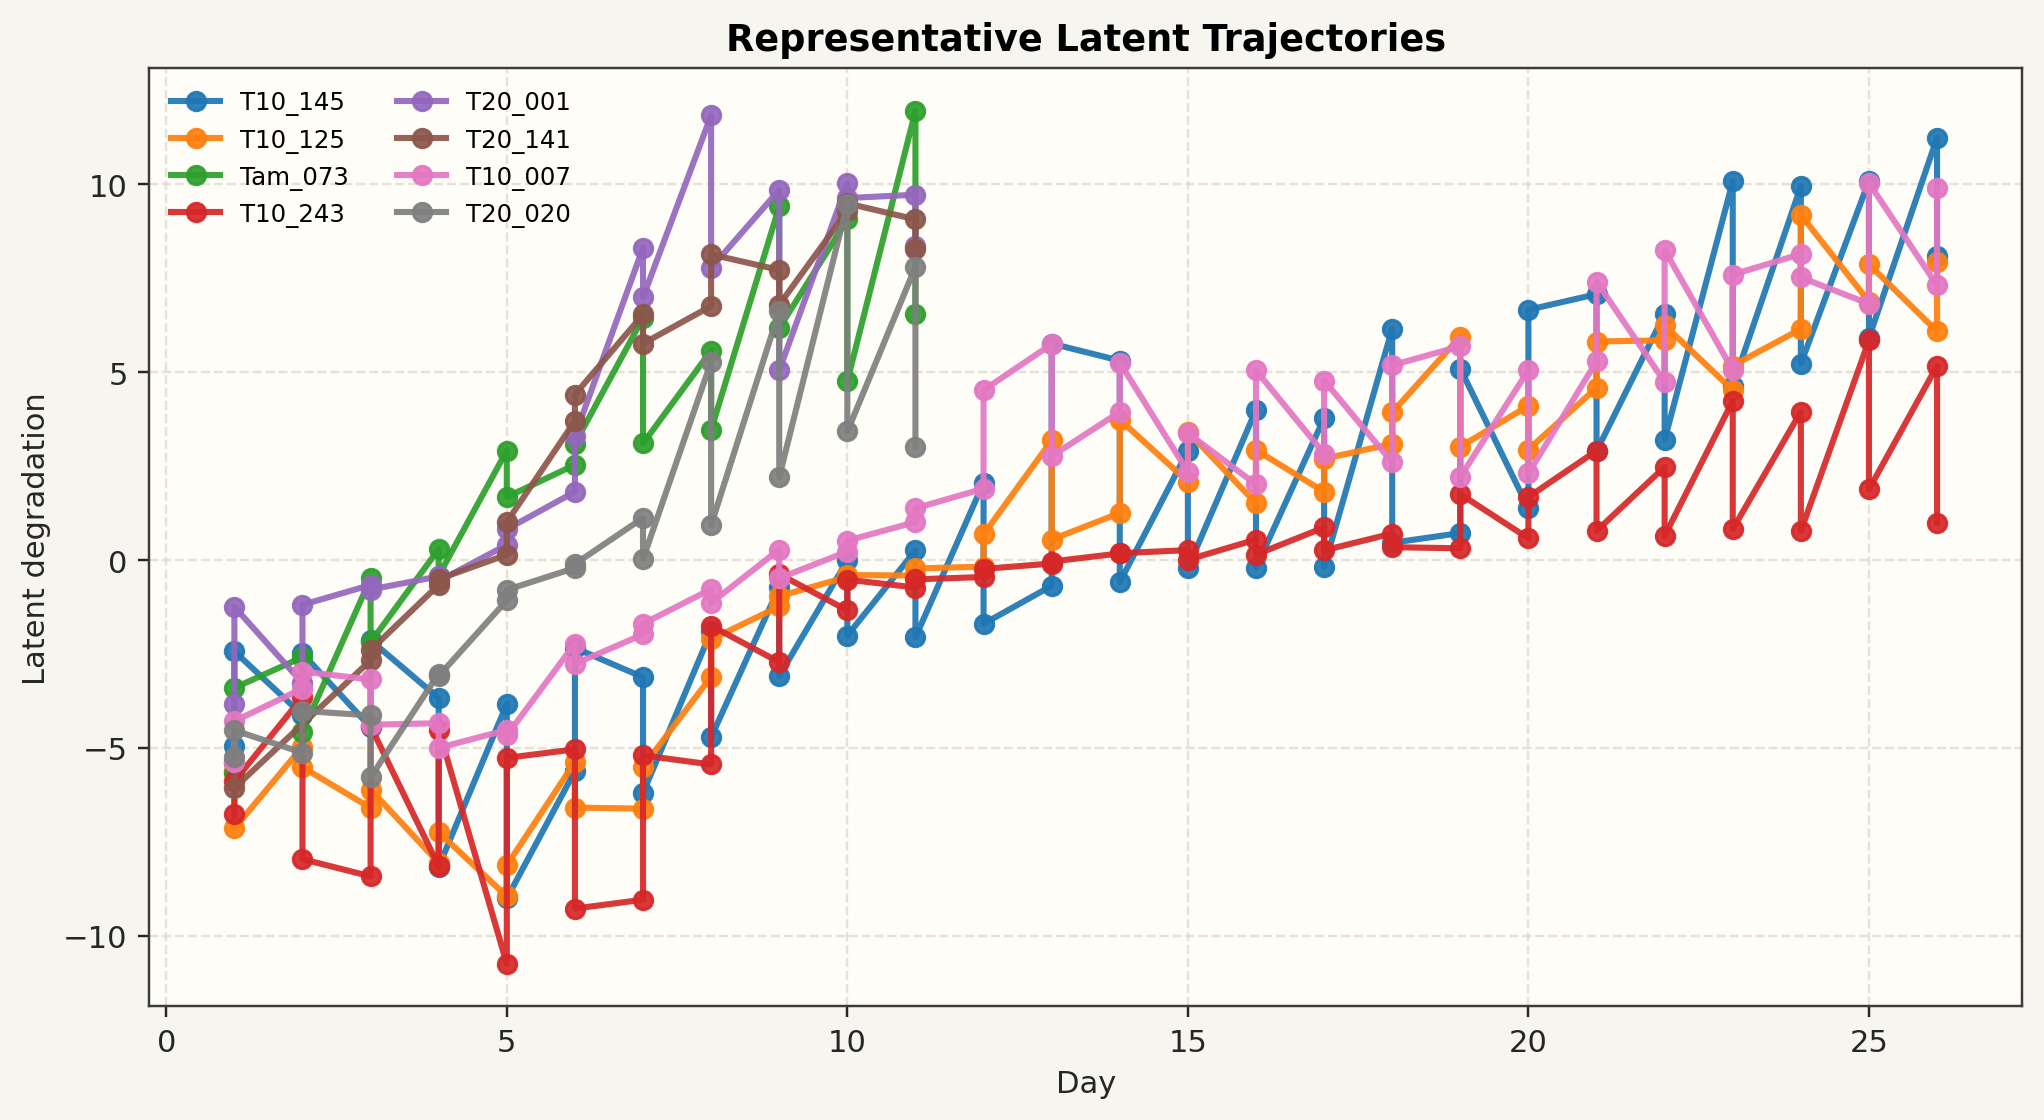

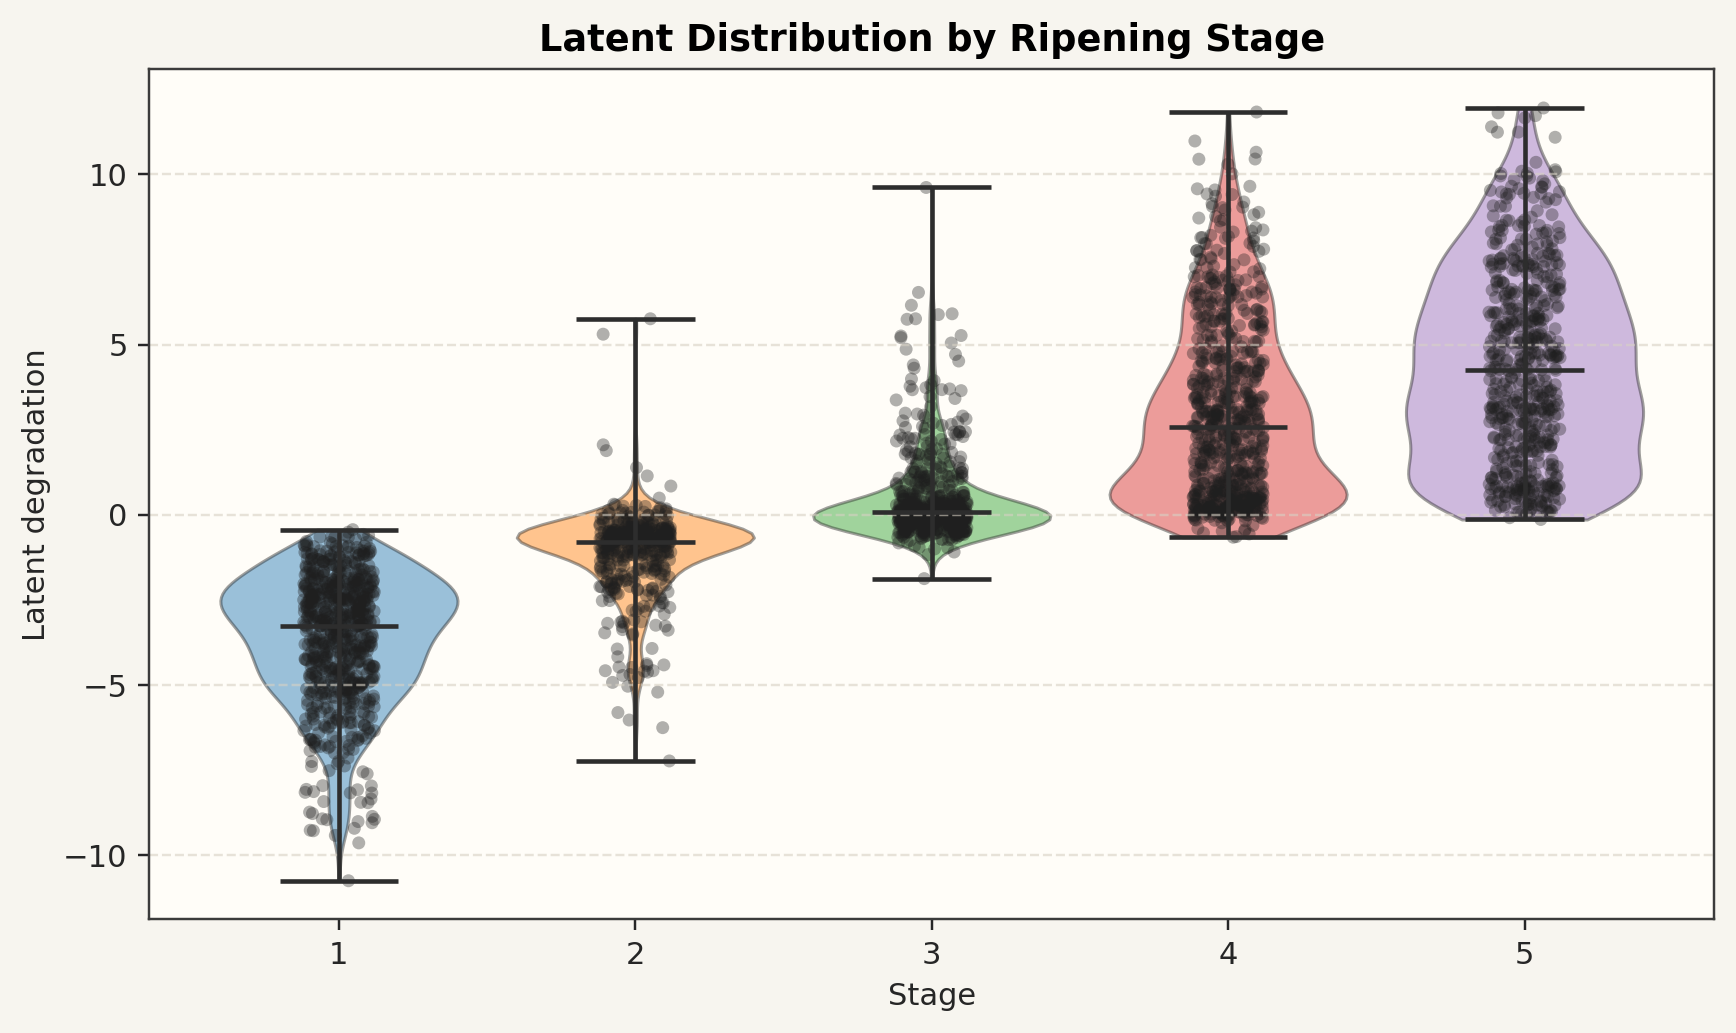

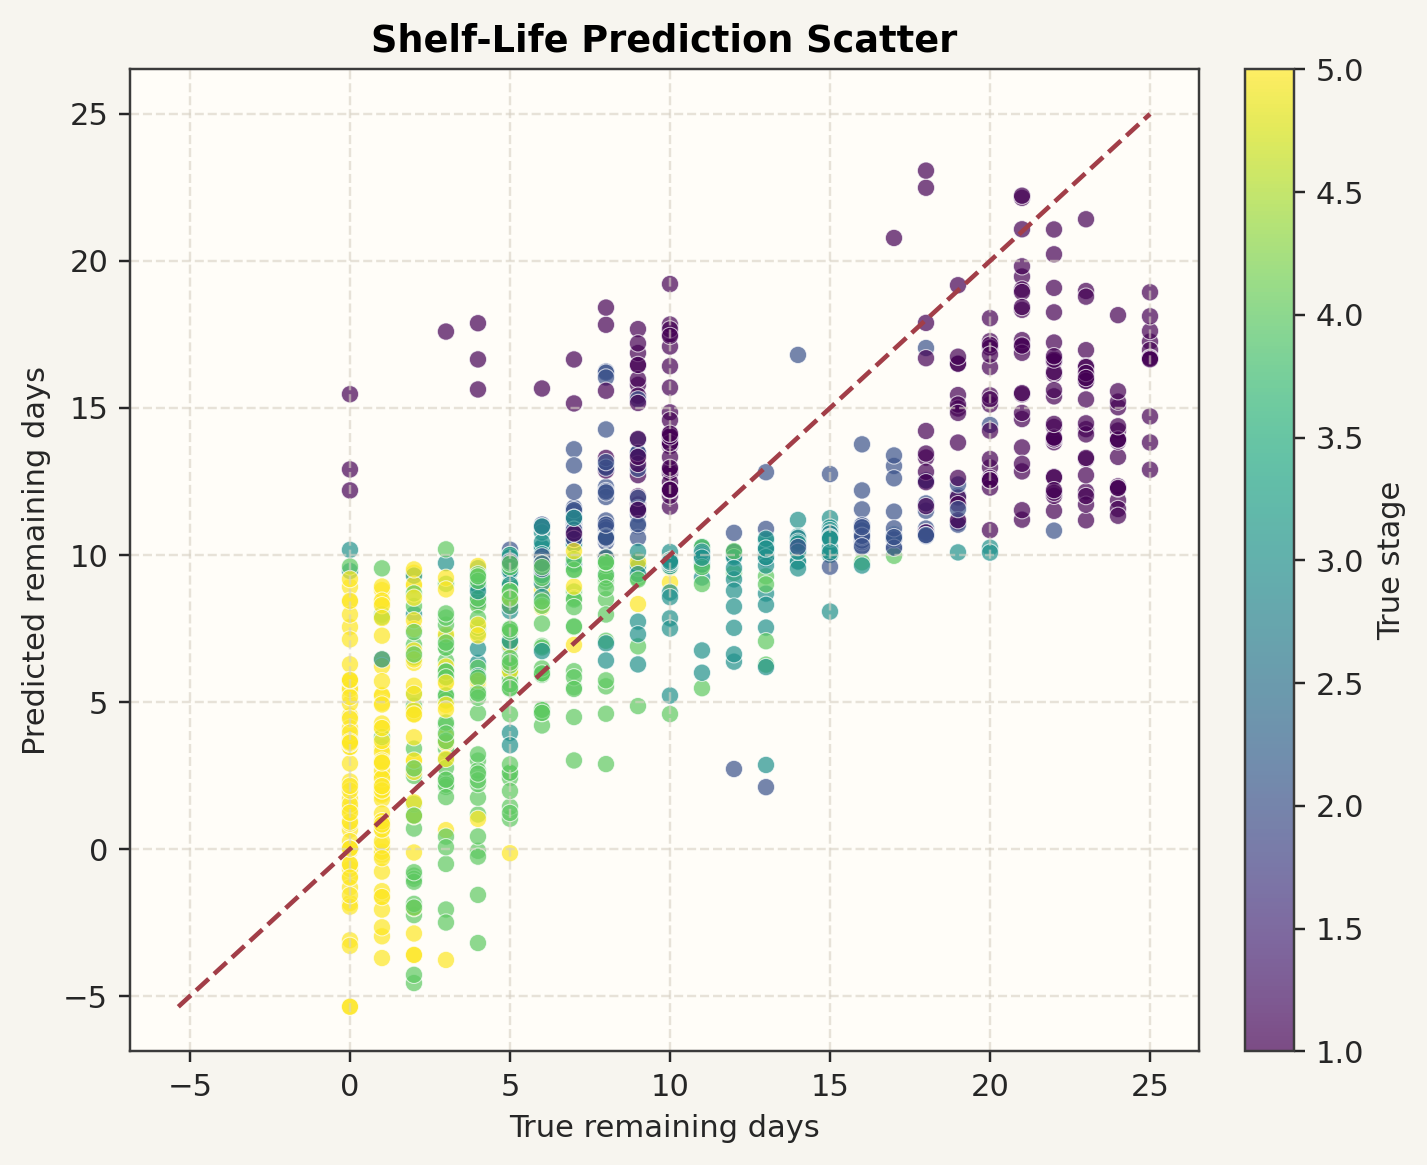

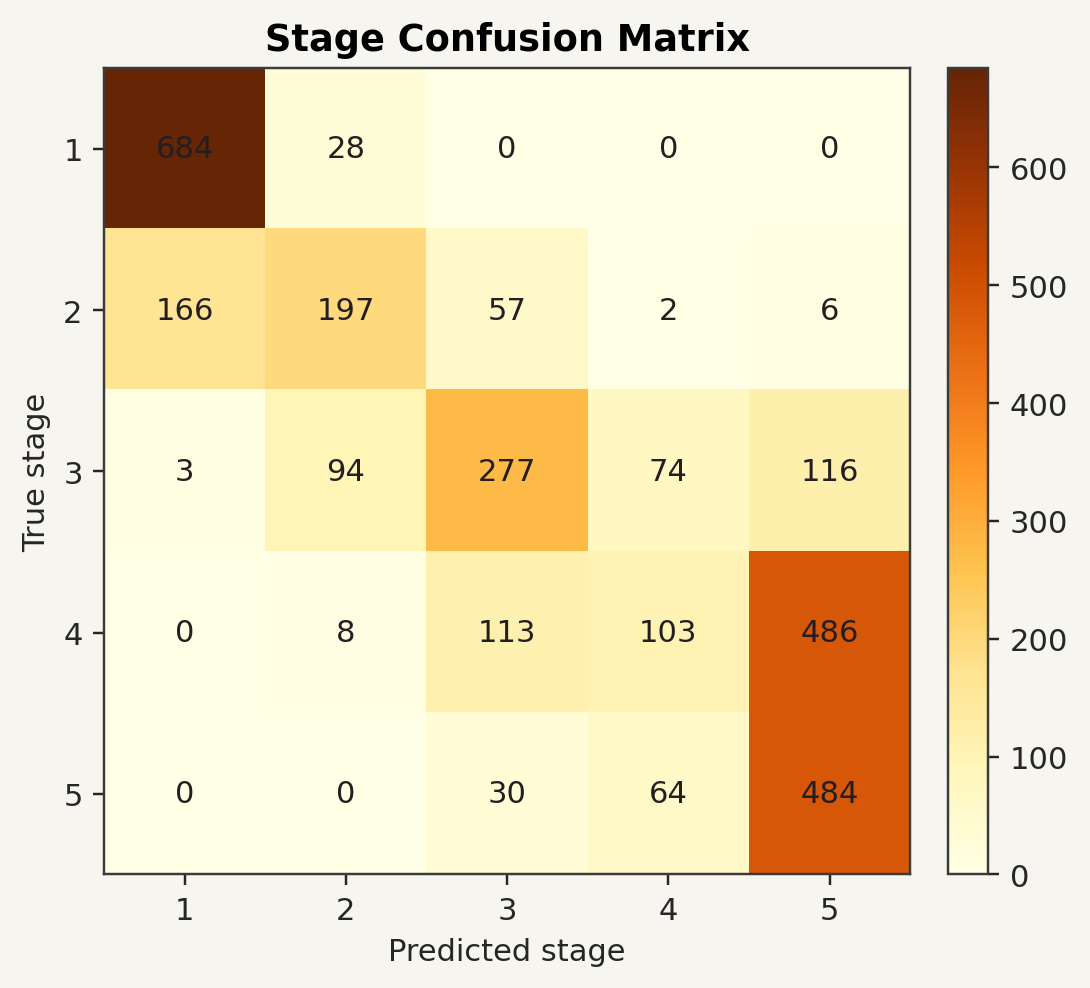

In [7]:
for path in paper_figures.values():
    display(Image(filename=str(path)))

## Exploratory Analysis

In [8]:
condition_summary = summarize_group_metrics(mld_predictions, group_col='storage_condition')

exploratory_figures = {
    'condition_metric_grid': plot_condition_metric_grid(
        condition_summary,
        exploratory_output_dir / 'condition_metric_grid.png',
    ),
    'training_curves': plot_training_curves(
        history_frame,
        exploratory_output_dir / 'training_curves.png',
    ),
    'metric_radar': plot_metric_radar(
        results_frame,
        exploratory_output_dir / 'metric_radar.png',
    ),
}

save_results_table(condition_summary, exploratory_output_dir / 'condition_summary.csv')
condition_summary

,model,storage_condition,sample_count,accuracy,macro_f1,qwk,mae,rmse,r2,spearman,monotonic_violation_rate
0,mld,T10,1734,0.607843,0.556232,0.876850,4.553392,5.537385,0.458854,0.839856,0.084162
1,mld,T20,664,0.542169,0.523012,0.876369,3.750002,4.423476,-0.951172,0.823662,0.080446
2,mld,Tam,594,0.557239,0.508571,0.880047,3.569200,4.170115,-0.738986,0.902065,0.070875


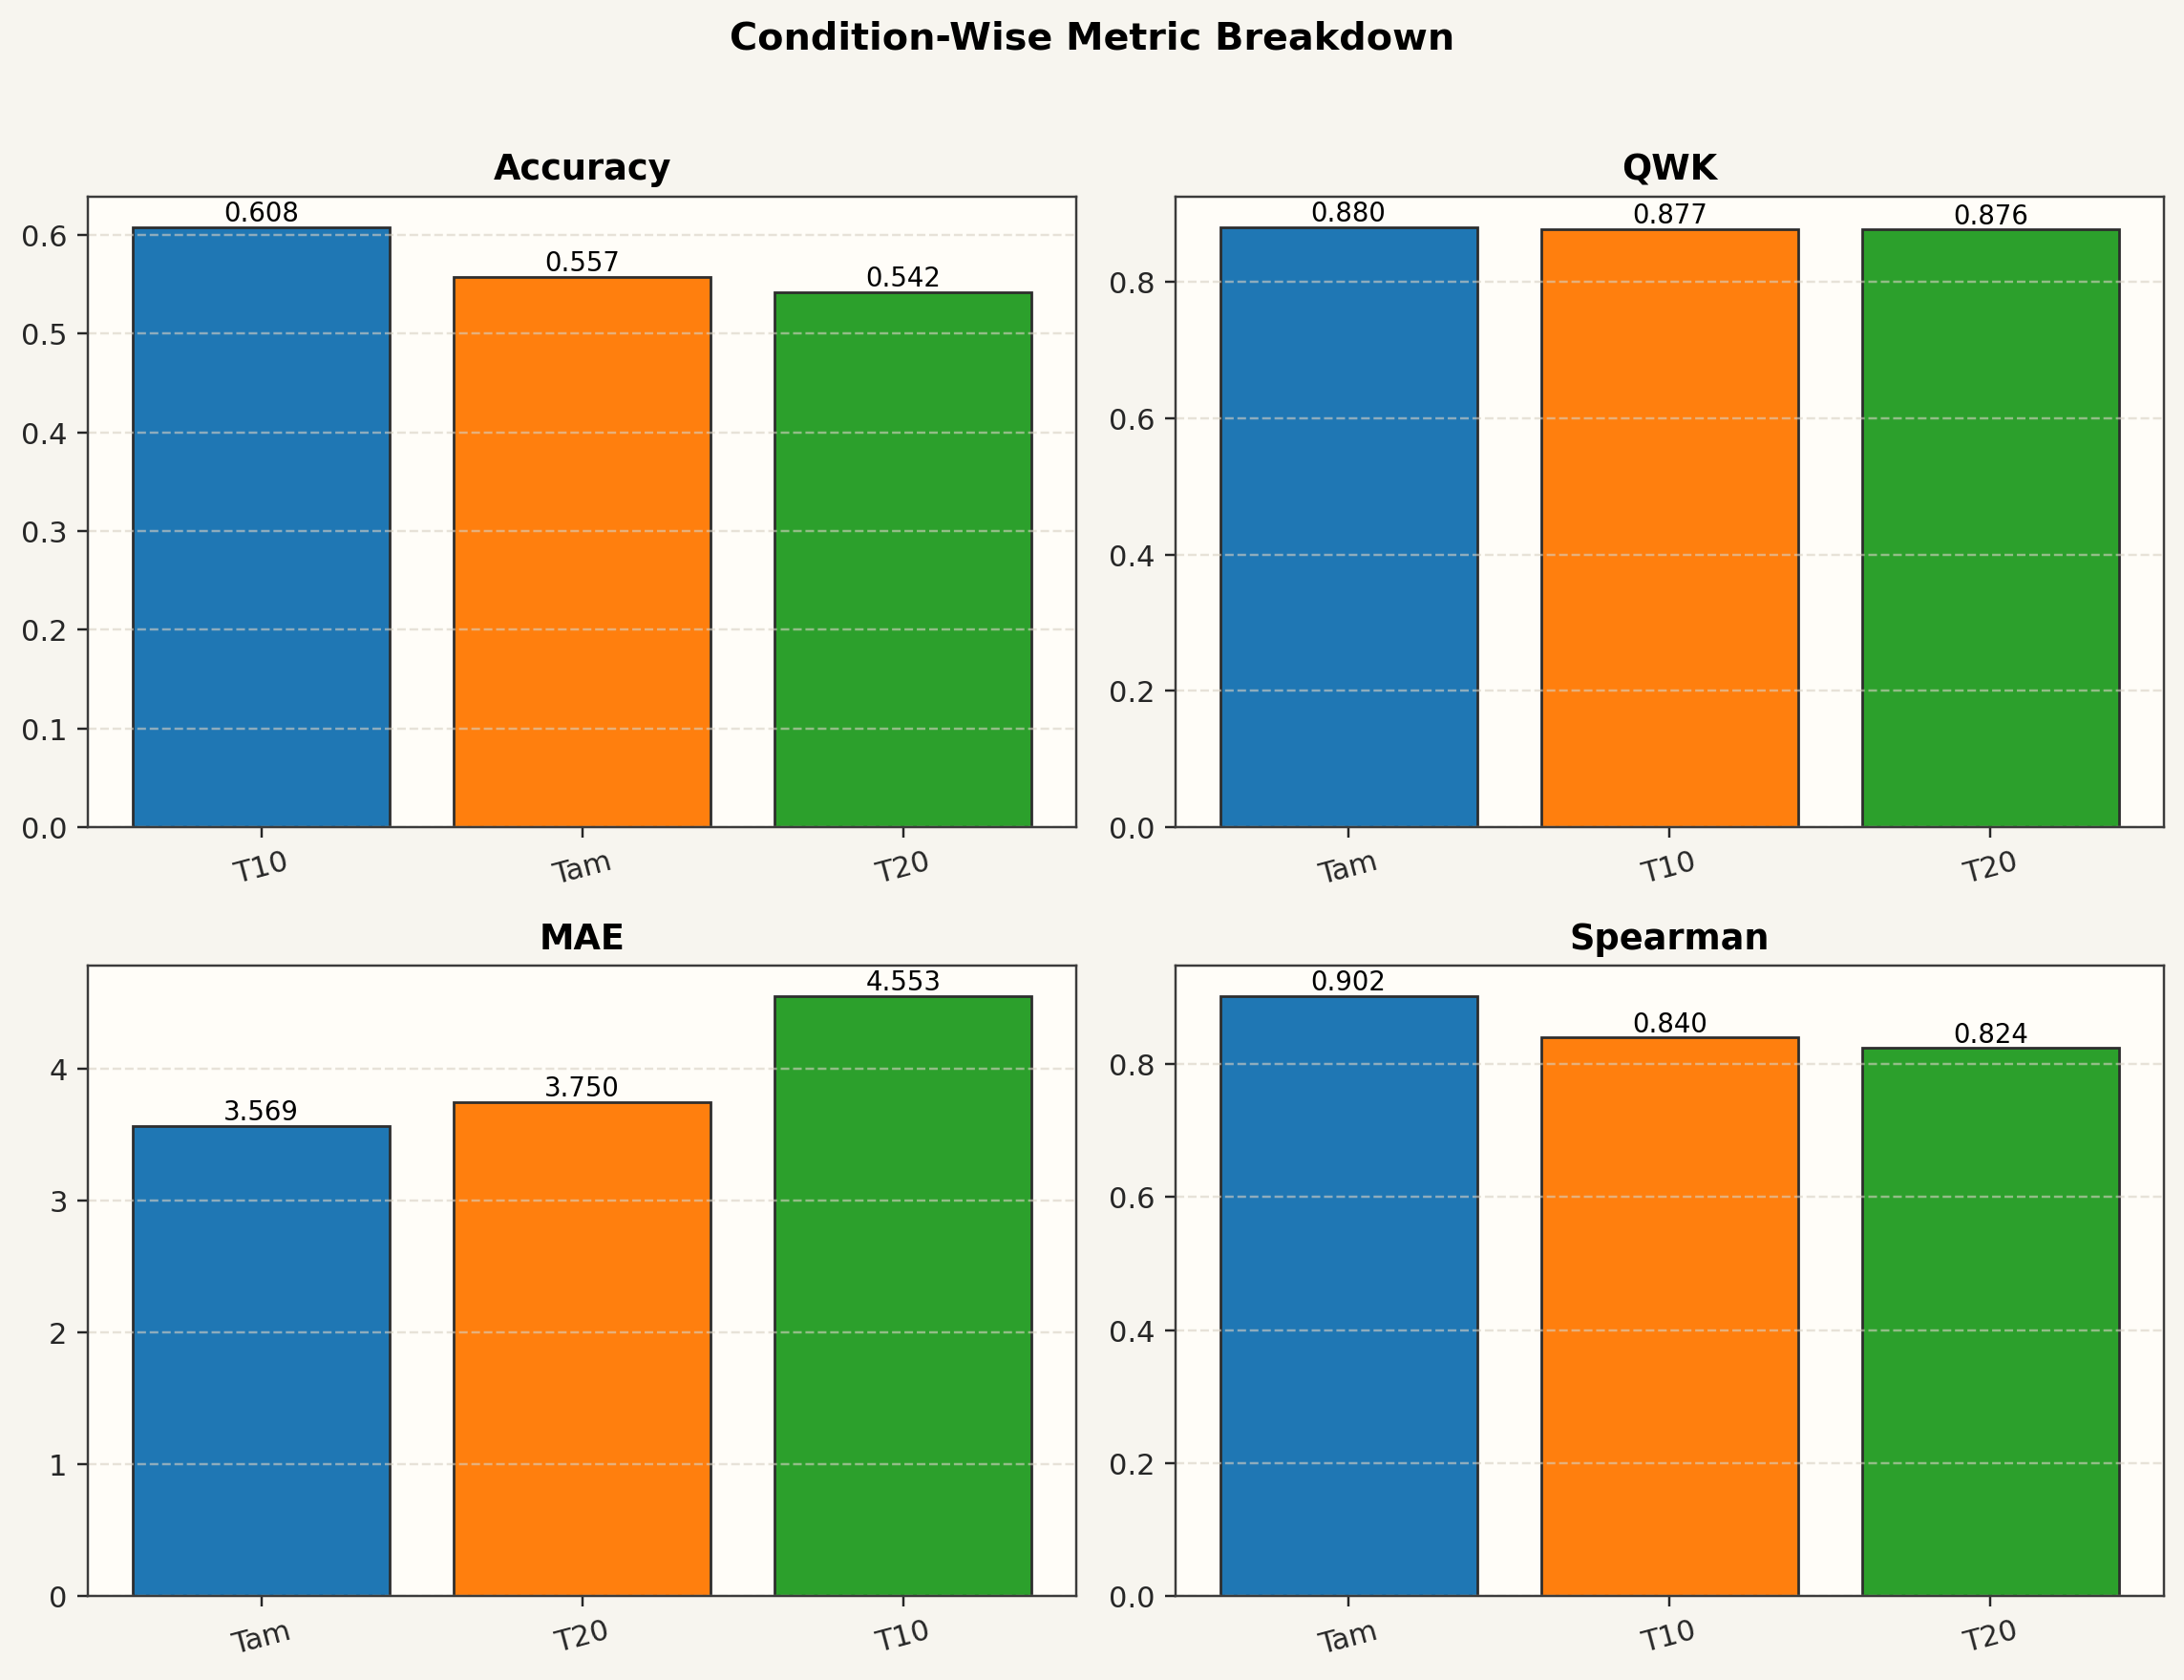

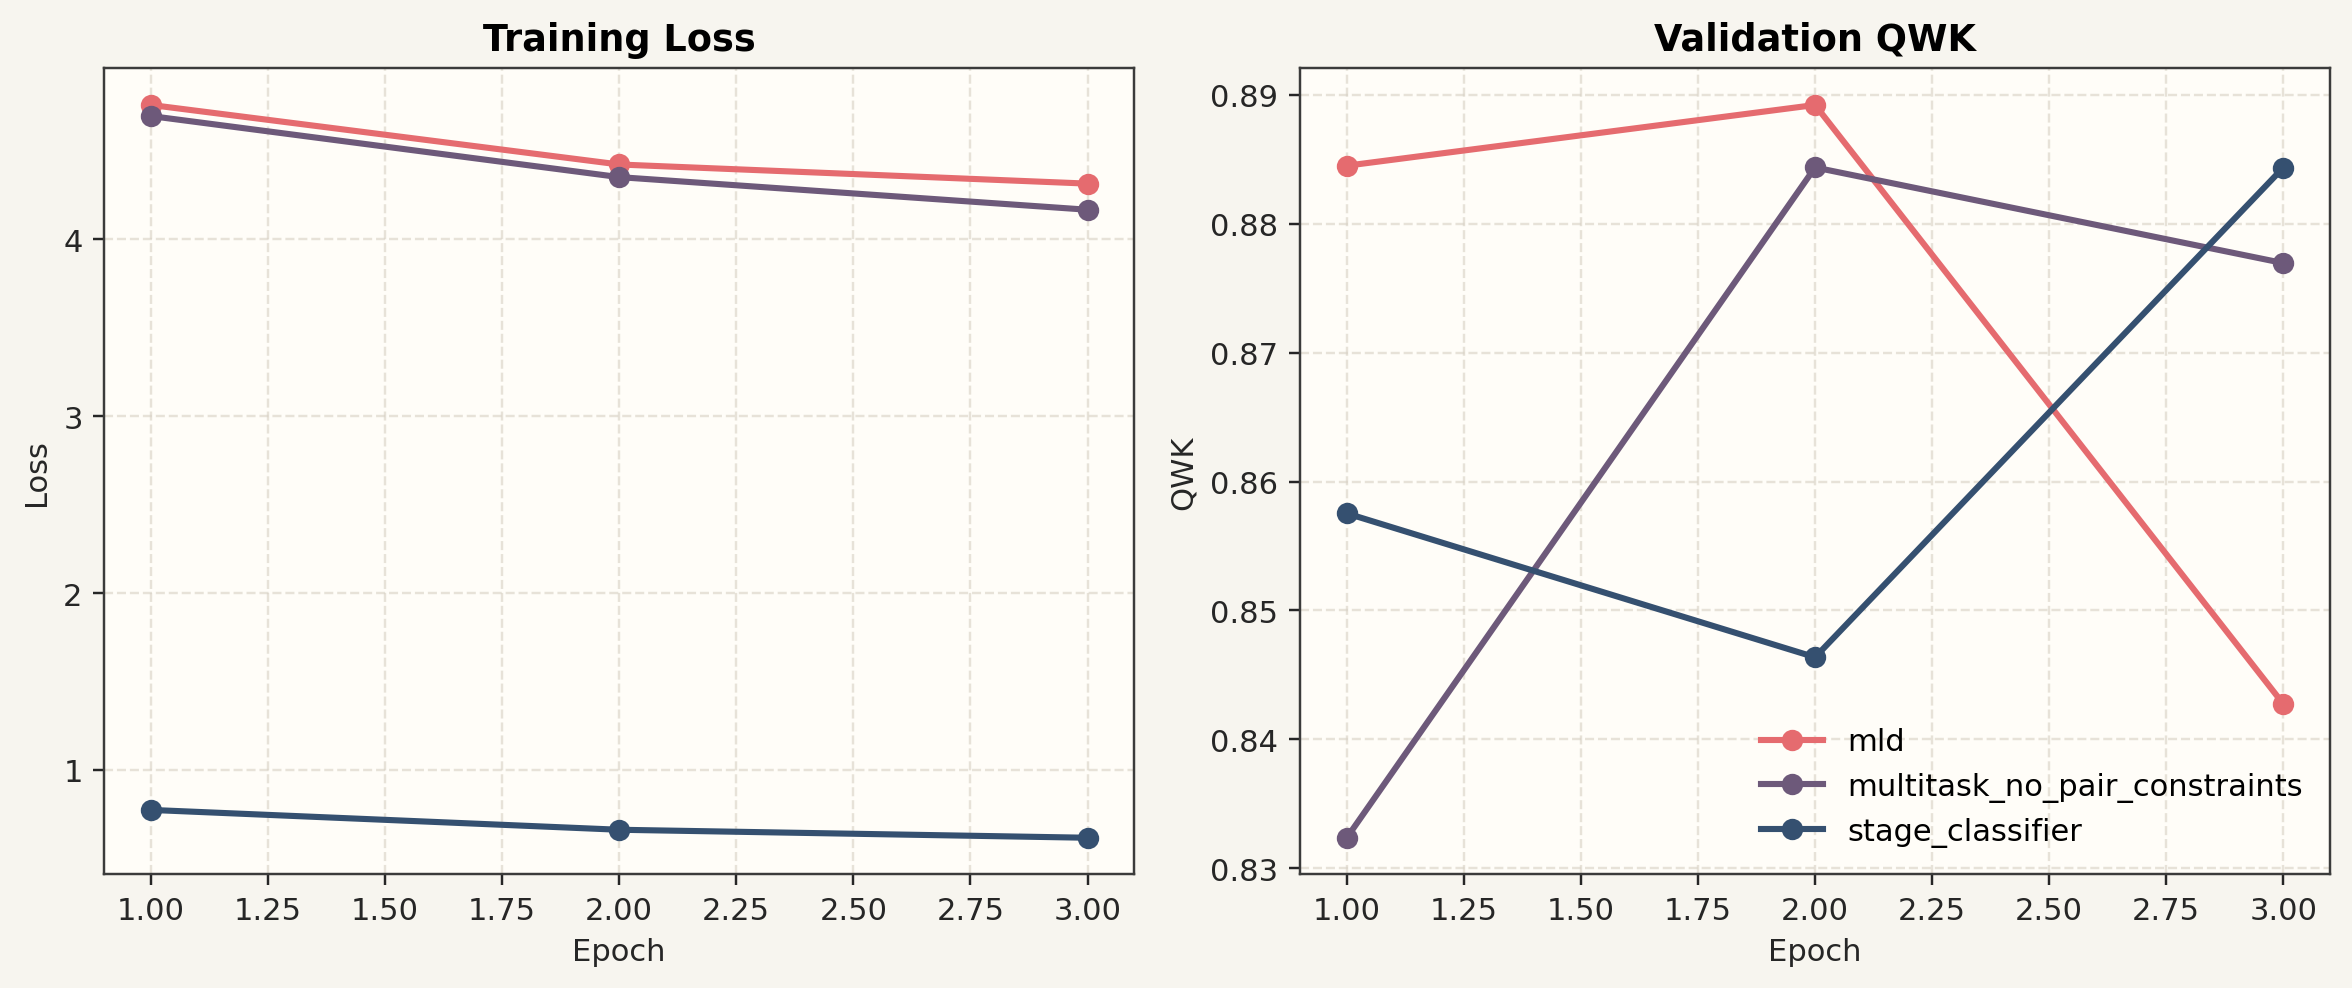

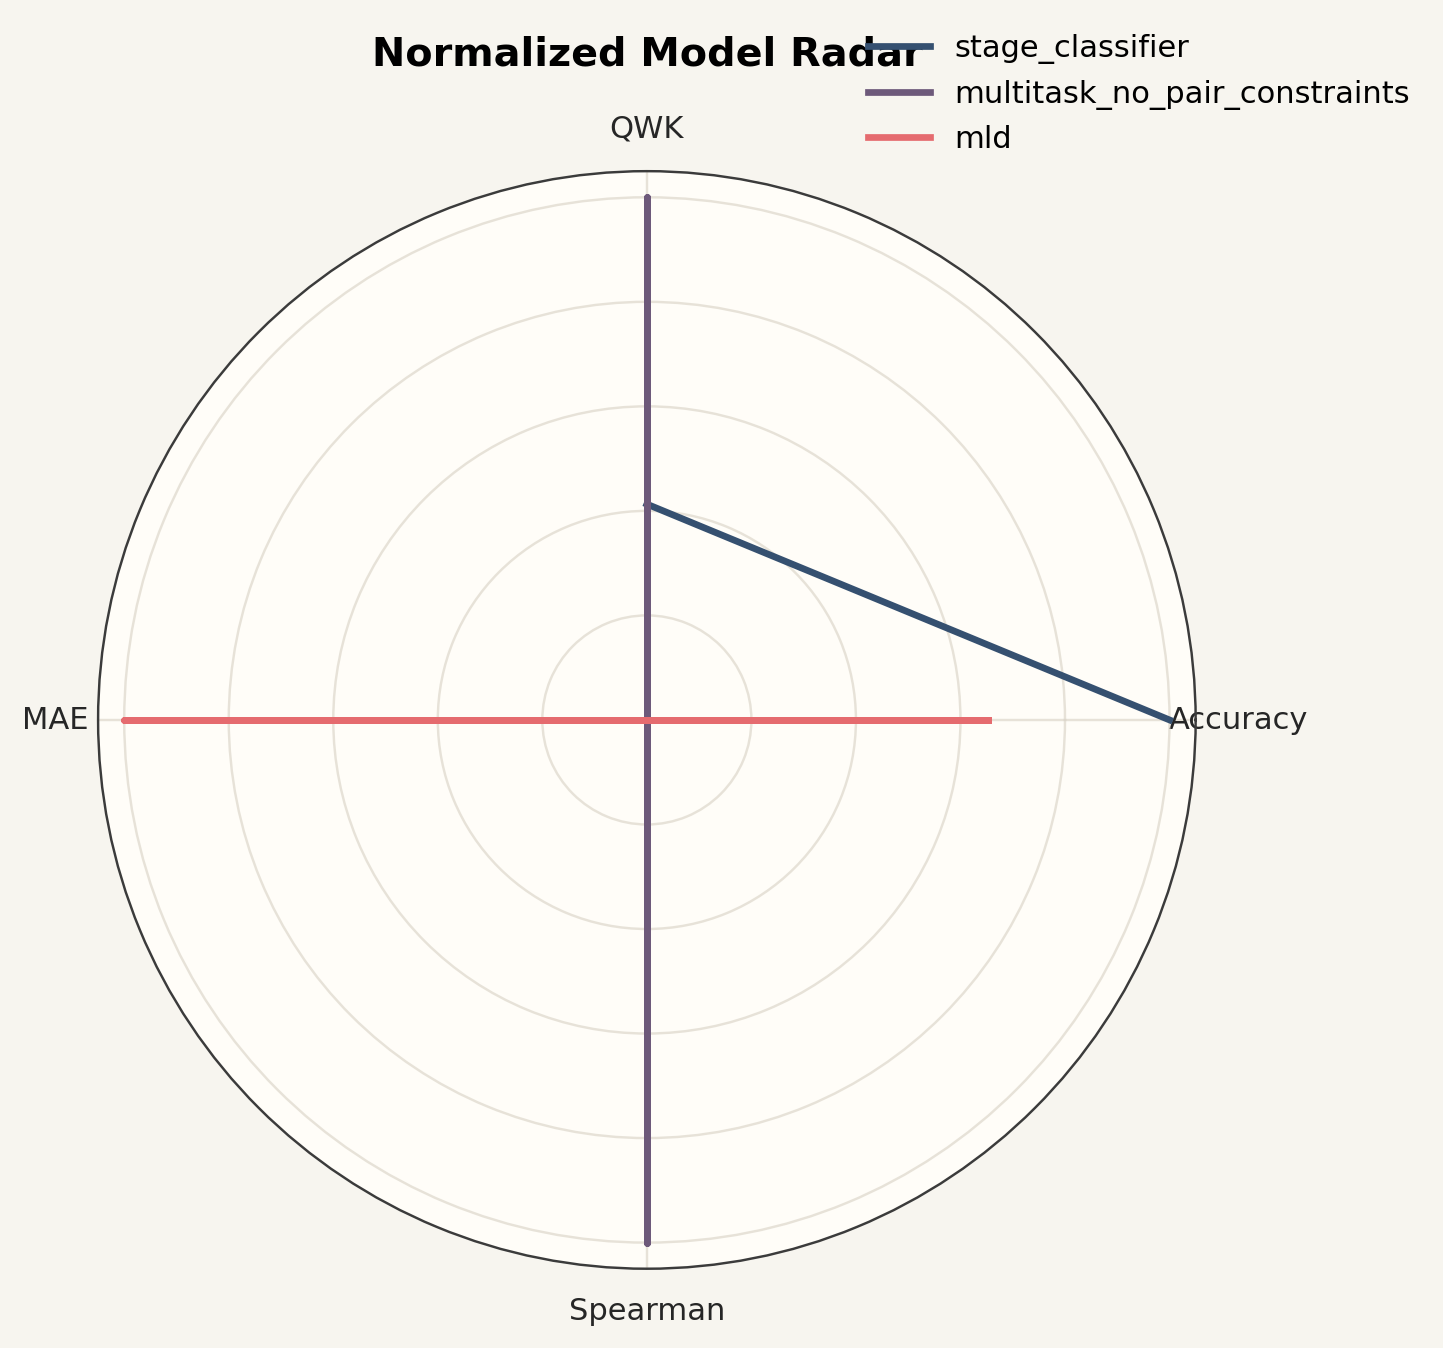

In [9]:
for path in exploratory_figures.values():
    display(Image(filename=str(path)))